# PHASE 1

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import timm
import matplotlib.pyplot as plt

c:\Users\rishi\OneDrive\Desktop\deep learning proj\dl_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # IMPORTANT for ViT
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

In [8]:
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,   # IMPORTANT
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform
)

In [9]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

print(len(train_dataset), len(val_dataset), len(test_dataset))

40000 10000 10000


In [10]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [11]:
model = timm.create_model('vit_tiny_patch16_224', pretrained=True)

model.head = nn.Linear(model.head.in_features, 10)

# Freeze backbone (faster training)
for param in model.parameters():
    param.requires_grad = False

for param in model.head.parameters():
    param.requires_grad = True

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using:", device)

Using: cuda


In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.head.parameters(), lr=1e-3)

In [14]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=3):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)

        # Validation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, preds = torch.max(outputs, 1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        acc = correct / total

        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Val Acc: {acc:.4f}")

In [15]:
train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=3)

Epoch [1/3] | Loss: 0.3318 | Val Acc: 0.9205
Epoch [2/3] | Loss: 0.2220 | Val Acc: 0.9258
Epoch [3/3] | Loss: 0.2158 | Val Acc: 0.9234


In [16]:
def evaluate(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    print("Test Accuracy:", correct / total)

evaluate(model, test_loader, device)

Test Accuracy: 0.9181


# PHASE 2

In [17]:
import torchvision.models as models

resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)
resnet = resnet.to(device)

c:\Users\rishi\OneDrive\Desktop\deep learning proj\dl_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\rishi\OneDrive\Desktop\deep learning proj\dl_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [18]:
optimizer_resnet = torch.optim.Adam(resnet.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

In [19]:
train_model(resnet, train_loader, val_loader, criterion, optimizer_resnet, device, epochs=2)

Epoch [1/2] | Loss: 0.3599 | Val Acc: 0.9325
Epoch [2/2] | Loss: 0.1684 | Val Acc: 0.9350


In [20]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

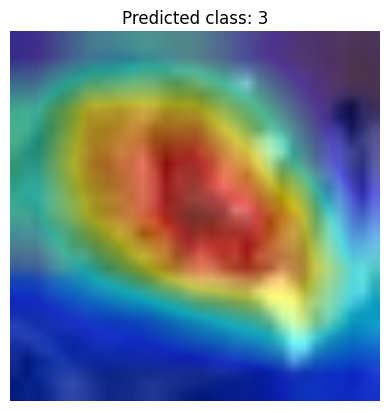

In [21]:
target_layer = resnet.layer4[-1]

cam = GradCAM(model=resnet, target_layers=[target_layer])

images, labels = next(iter(test_loader))
image = images[0].unsqueeze(0).to(device)

# Get prediction
outputs = resnet(image)
pred_class = outputs.argmax(dim=1).item()

# Generate CAM
grayscale_cam = cam(input_tensor=image, targets=[ClassifierOutputTarget(pred_class)])
grayscale_cam = grayscale_cam[0]

# Prepare image
img = image.squeeze().permute(1,2,0).cpu().numpy()
img = (img - img.min()) / (img.max() - img.min())

visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

import matplotlib.pyplot as plt
plt.imshow(visualization)
plt.axis("off")
plt.title(f"Predicted class: {pred_class}")
plt.show()

# PHASE 3

In [22]:
import requests

In [23]:
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [24]:
def get_top3(outputs):
    probs = torch.softmax(outputs, dim=1)
    top3 = torch.topk(probs, 3)

    result = []
    for i in range(3):
        cls = top3.indices[0][i].item()
        conf = top3.values[0][i].item()
        result.append(f"{classes[cls]} ({conf:.2f})")

    return result

In [27]:
def generate_llm_explanation(pred_class, confidence, top3=None):
    label = classes[pred_class]

    extra = ""
    if top3:
        extra = "Top predictions: " + ", ".join(top3)

    prompt = f"""
You are an AI explaining an image classification result.

Prediction: {label}
Confidence: {confidence:.2f}
{extra}

The model focused on the main object region.

Explain clearly why this prediction was made.
"""

    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": "llama3:8b",
            "prompt": prompt,
            "stream": False
        }
    )

    result = response.json()

    # 🔥 DEBUG PRINT (important)
    print("LLM RAW RESPONSE:", result)

    # Safe return
    if "response" in result:
        return result["response"]
    else:
        return f"Error from LLM: {result}"

In [28]:
outputs = model(image)

pred_class = outputs.argmax(dim=1).item()
confidence = torch.softmax(outputs, dim=1)[0][pred_class].item()

top3 = get_top3(outputs)

explanation = generate_llm_explanation(pred_class, confidence, top3)

print("Prediction:", classes[pred_class])
print("Confidence:", confidence)
print("\nExplanation:\n", explanation)

LLM RAW RESPONSE: {'model': 'llama3:8b', 'created_at': '2026-03-30T19:48:28.9500829Z', 'response': "A confident prediction!\n\nAfter analyzing the image, our AI model has determined that the primary object depicted is indeed a cat. This conclusion is based on several key features and patterns detected in the image.\n\nFirstly, the model identified the cat's body shape, including its distinctive rounded ears, whiskers, and fluffy coat. These characteristics are consistent with those of felines.\n\nSecondly, the AI recognized the cat's facial structure, including the eyes, nose, and mouth. The shape and size of these features match those typically found on a cat's face.\n\nThirdly, the model took into account the overall context and composition of the image. In this case, there are no other objects or distractions that would suggest the presence of a different animal, such as a dog or frog.\n\nThe confidence score of 1.00 indicates that our AI model is extremely certain about its predict

In [29]:
torch.save(model.state_dict(), "vit_model.pth")
torch.save(resnet.state_dict(), "resnet_model.pth")